# KymoTracker diffusion and position analysis, with hand drawn trace initialisation

version: 01 Apr 2025 |  Benjamin Ambrose  

David Rueda lab - Single-Molecule Imaging Group at LMS MRC/Imperial College London

--------------------------------------------------------------------------------

Modified version of .ipynb from Artur Kaczmarczyk (09 November 2022) using built in pylake tracking algorithm

Features of the script:
- No genomic positioning using bead centers in this version, use other version if you need that
- Single-particle tracking via hand drawn trace selection and gaussian refinement
- Exports track with position in um and bp along with intensity
- Exports metadata file containing details needed to reproduce analysis

Key differences from 09 November 2022 Script:
- Traces are initialised by hand drawing rather than via peak detection, removing need to carefully tweak parameters in order to get the algorithm to recognise the molecule.
- Picked traces are then refined using built in pylake algorithm. This uses full downsampling rather than sliding window, so the MSD/tau plot is not distorted at tau = 1 and tau = 2 and data is not double counted.
- Meta data with your analysis parameters is saved, as well as the initialisation scribble, so that tracks can be reproduced with a batch script if necessary (tbd)

Other notes:
- The words track and trace are used interchangeably here
- You will need to install the cv2 package to get this to work, but this can be done quite easily
- DNA length of 48501 bp (lambda) is assumed, edit if necessary

In [1]:
import lumicks.pylake as lk
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn
try: #will attempt to use catppuccin for darkmode viewing, reverts to default colors if not available
    import mplcatppuccin
    mpl.style.use("mocha")
    from mplcatppuccin.palette import load_color
except:
    'no catppuccin, using default colors'
import numpy as np
import peakutils
import matplotlib.patheffects as pe
import pandas as pd
import tkinter as tk
import PIL.Image, PIL.ImageTk
import cv2
from lumicks.pylake.kymotracker.kymotrack import KymoTrack, KymoTrackGroup
import statistics


This code will search for a kymo .h5 in the directory this notebook is in

In [2]:
filenames = os.listdir('./')  
Filenames = []
for filename in filenames:                      # select .h5 files only
    if filename[-3:] == '.h5':
        Filenames.append(filename)
if len(Filenames) > 1:
    print('Mutiple .h5 files found')
name = str(Filenames[0])                        # if there is more .h5 in the directory, change the index 0 to 1 or more
print("Imported file: " + name)
file = lk.File(name)

kymo = file.kymos[[key for key in file.kymos][0]] #this just yields the first kymo in the first file. This is probably the kymo you are after

Imported file: EXAMPLEKYMO.h5


This gives an RGB picture of the whole kymo

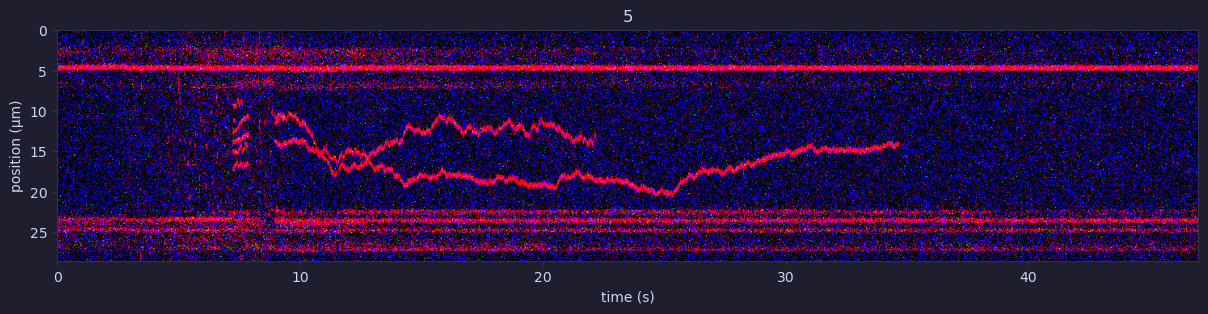

In [3]:
plt.figure(figsize=(25,3))
kymo.plot('rgb', adjustment=lk.ColorAdjustment(0,94, mode ='percentile'))
if not os.path.exists('images'):
    os.makedirs('images')
plt.savefig('images/fullkymo.png')

Here, select which of the peaks that have been found correspond to the bead centers. Unless the bead centers are very dim or your molecules are very bright, it will have only found the two bead centers in which case you should input 0 and 1.

This time select the color of your molecules, and it will display cumulative intensity in bp.

The way this works is that find the positions of the edges of the beads by adding/subtracting 1/2 bead diameter to the bead center positions. We know how far this distance is in um because we know pixel size (it is saved in the kymo) and we know that there should be 48502 bp between these two positions. Note that the interpolation done below simply creates a new x axis for the plot shown. The conversion of positions into bp is done later in the notebook, using seperate calculation, as tracked molecule positions have subpixel precision.

## Tracking

Now we can track the molecules. We'll start by showing the whole kymo again for ease of selecting cropping numbers

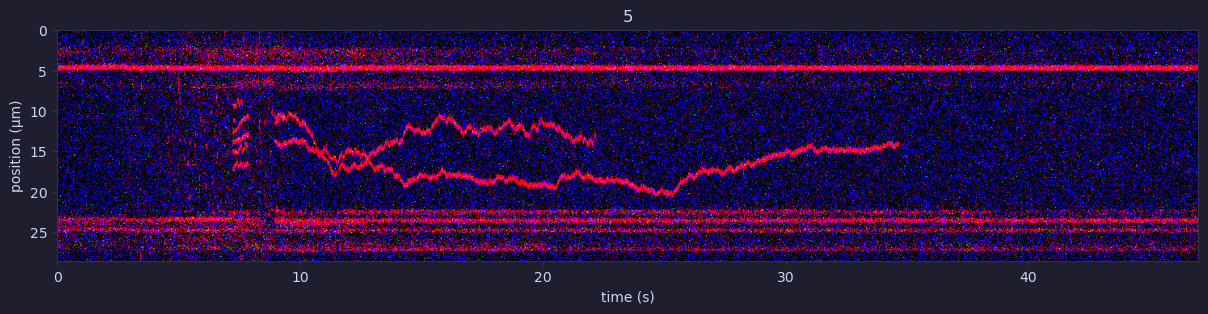

In [5]:
plt.figure(figsize=(25,3))
kymo.plot('rgb', adjustment=lk.ColorAdjustment(0,95, mode ='percentile'), cmap='afmhot')

Now choose the crop positions for the tracks you are interested in. The crop positions are in um and seconds as in the kymo above.

The time_factor variable will downsample the data in time (eg. combining every 3 frames into 1 frame). This improves signal to noise for tracking purposes, but if your signal to noise is extremely good you may be able to get away with setting this to 1.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


<Figure size 2500x300 with 0 Axes>

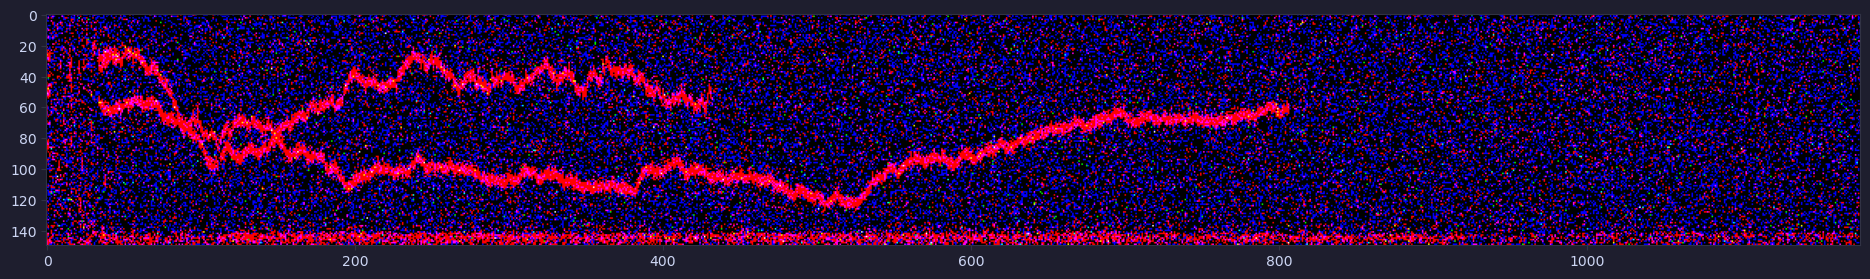

In [6]:
pos1 = 8
pos2 = 23
t1 = 8
t2 = 100

time_factor = 3

t1, t2 = str(t1)+'s', str(t2)+'s'
plt.figure(figsize=(25,3))
croppedkymo = kymo[t1:t2].crop_by_distance(pos1, pos2)
croppedkymo_ds = croppedkymo.downsampled_by(time_factor=time_factor)
image = croppedkymo.get_image('rgb')
topval = np.percentile(image.flatten(), 99.5)
image = image**(1/2)*255/topval**(1/2) #normalise to sqrt of 99.5 percentile
plt.figure(figsize=(25,3))
plt.imshow(image)
plt.savefig('images/croppedkymo.png')

Now we can select which tracks to analyse. You can put scaling factors here which will make the kymo bigger or smaller on your screen. You can then draw on the tracks in the gui. You can either hold down left click for fine control or do single clicks to draw straight lines, the refinement algorithm later on will attempt to fill in the gaps. Press D to save a trace and draw another one, or A to clear the drawing and start again. Close the gui when you are done but press D to save the trace first!

These drawings do not have to be perfect, the refinement algorithm later on will look within a window around your drawing in order to refine it. If your drawing is super imprececise you can just increase this window, but for a crowded kymo this isn't a great idea so try not to be too messy.

If you are going to move/resize the window it may be a good idea to hit [a] after just to remove any mouse clicks that may have been registered

In [7]:
scalingx = 1 #scaling factors for the kymo image
scalingy = 3

#color correction
gamma = 0.5 #adjust down to change how much the bright foci 'pop' 
red = croppedkymo.get_image('rgb')[:,:,0]
red = 255*red**gamma/max(red.flatten()**gamma)
grn = croppedkymo.get_image('rgb')[:,:,1]
grn = 255*grn**gamma/max(grn.flatten()**gamma)
blu = croppedkymo.get_image('rgb')[:,:,2]
blu = 255*blu**gamma/max(blu.flatten()**gamma)
rgb = np.dstack((red,grn,blu))

bigimage = cv2.resize(rgb, (0,0), fx=scalingx, fy = scalingy).astype(np.uint8) #I called this bigimage, but it could theoretically be smaller if the scaling factors <1
height, width, ncolours = np.shape(bigimage)
drawn_x_coordinates = set()
drawn_positions = []
saved_traces = []
def draw(event): #handles drawing of new lines
    x, y = event.x, event.y
    if y > 0: #only draws if in frame. Allows you to move the window without drawing
        if drawn_positions:
            x0,y0 = drawn_positions[-1]
            canvas.create_line(x0, y0, x, y, fill='white', width = 2, tags = ['currentscribble'])
        if x not in drawn_x_coordinates:
            drawn_x_coordinates.add(x)
            drawn_positions.append((x,y))
            canvas.create_oval(x-1, y-1, x+1, y+1, fill='white', tags = ['currentscribble'])
def clear(event): #handles the clearing of drawn lines
    global drawn_positions
    global drawn_x_coordinates
    canvas.delete('currentscribble')
    drawn_positions = []
    drawn_x_coordinates = set()
def save(event): #this moves the drawn track from drawn_positions into saved_traces, then clears drawn_positions ready for the next trace
    global drawn_positions
    global drawn_x_coordinates
    x0, y0 = drawn_positions[0]
    for xy in drawn_positions: #redraws the lines in magenta
        x, y = xy
        canvas.create_line(x0, y0, x, y, fill='magenta', width = 2)
        x0, y0, = x, y
    canvas.delete('currentscribble') #removes the lines already drawn in the active color
    saved_traces.append(drawn_positions)
    drawn_positions = []
    drawn_x_coordinates = set()
root = tk.Tk()
canvas = tk.Canvas(root, width=width, height=height+50)
canvas.pack()
photo = PIL.ImageTk.PhotoImage(image = PIL.Image.fromarray(bigimage))
canvas.create_image(0, 0, image=photo, anchor='nw', )
canvas.create_text(150,height+25, text='[a] to delete scribble, [d] to save scribble', fill='white')
root.bind('<B1-Motion>', draw)
root.bind('<Button-1>', draw)
root.bind('d', save)
root.bind('a', clear)
root.mainloop()

This will show the tracks you drew, with numbers on, so you can check that it came out okay.

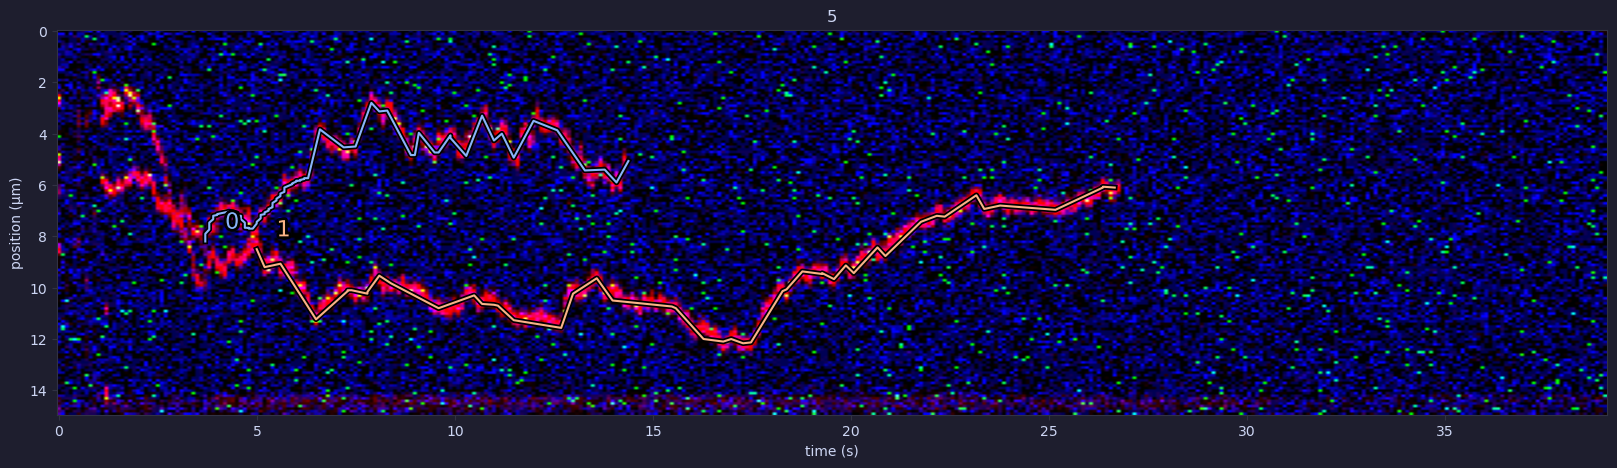

In [8]:
channel = color
#spoofing the tracks as if they were og pylake objects
tracks = []
for trace in saved_traces:
    cleanedtrace = [x for x in trace if x[1] > 0] #removes mouseclicks above the frame (from repositioning etc.)
    times = [int(x[0]/(scalingx*time_factor)) for x in cleanedtrace] #correct for time factor
    positions = [x[1]/scalingy for x in cleanedtrace]
    track = KymoTrack(time_idx = times, localization = positions, kymo = croppedkymo_ds, channel = channel, minimum_observable_duration=None)
    tracks.append(track)
tracks = KymoTrackGroup(tracks)
plt.figure(figsize=(20,5))
croppedkymo_ds.plot(channel='rgb', aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='afmhot')
for i, track in enumerate(tracks):
    t, pos = track.seconds, track.position
    g = plt.plot(t, pos, linewidth = 1.5, path_effects=[pe.withStroke(linewidth=4, foreground="black")]) #the path effect here drops a black shadow for visibility
    plt.annotate(i, (t[0]+0.5, pos[0]-0.5), fontsize=16, color=g[0].get_color(), path_effects=[pe.withStroke(linewidth=4, foreground="black")])
plt.savefig('images/trackedkymo.png')

Now we can refine the tracks by fitting a gaussian peak in a window around the hand drawn track. Note that 'gaussianrefinementwindow' refers to the number of pixels either side of the greedy track. So the actual size of the window that is checked is 2N+1

overlap_strategy='simultaneous' allows it to refine all traces in the group at the same time, so if they come close to each other they will not be confused/combined.

In [9]:
gaussianrefinementwindow = 5
refinedtracks = lk.refine_tracks_gaussian(tracks, window = gaussianrefinementwindow, refine_missing_frames=True, overlap_strategy='simultaneous')

This will display the hand drawn tracks and the refined tracks

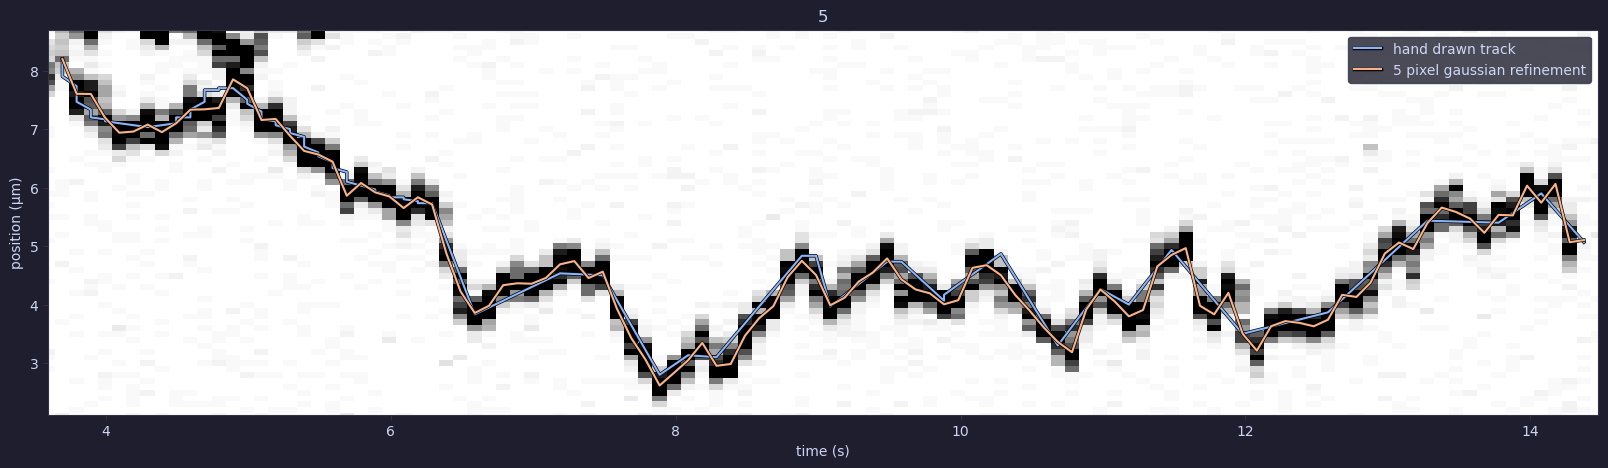

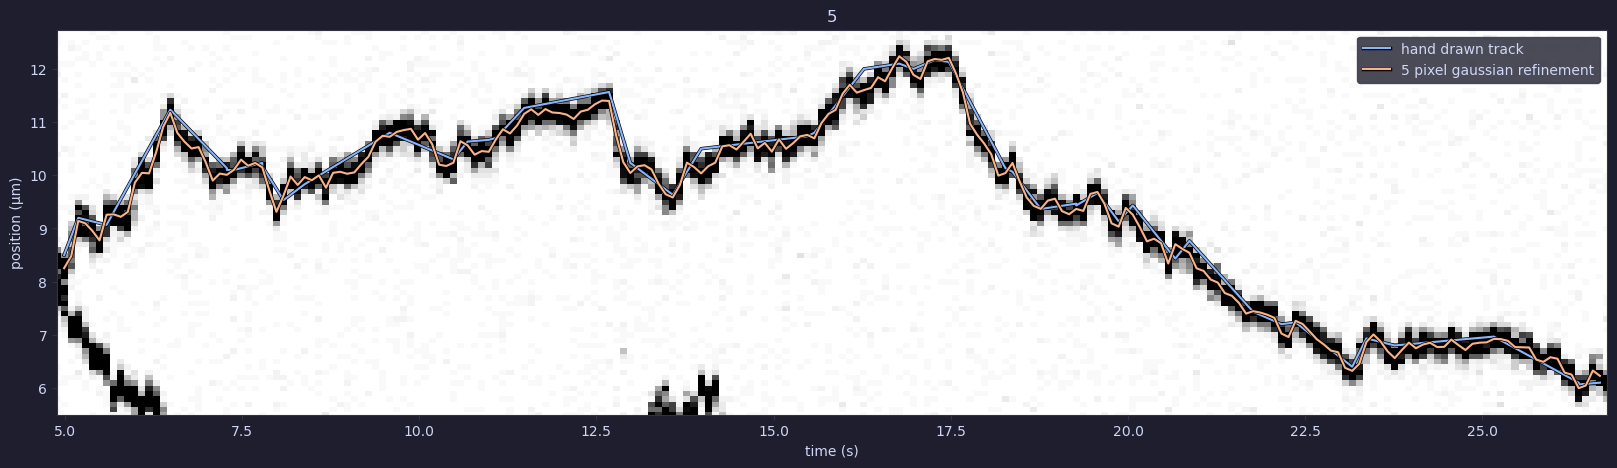

In [10]:
for i, track in enumerate(tracks):
    refined = refinedtracks[i]
    plt.figure(figsize=(20,5))
    croppedkymo_ds.plot(channel=color, aspect = 'auto', adjustment=lk.ColorAdjustment(0, 98, mode="percentile"), cmap='Greys', zorder=1)
    plt.plot(track.seconds, track.position,linewidth=1.5, label='hand drawn track', path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
    plt.plot(refined.seconds, refined.position, linewidth = 1.5, label=str(gaussianrefinementwindow)+ ' pixel gaussian refinement',  path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])
    plt.xlim(min(refined.seconds)-0.1,max(refined.seconds)+0.1)
    plt.ylim(min(refined.position)-.5,max(refined.position)+.5)
    plt.legend()
    plt.savefig('images/trace'+str(i)+'tracks.png')

This will plot the intensities of your selected traces

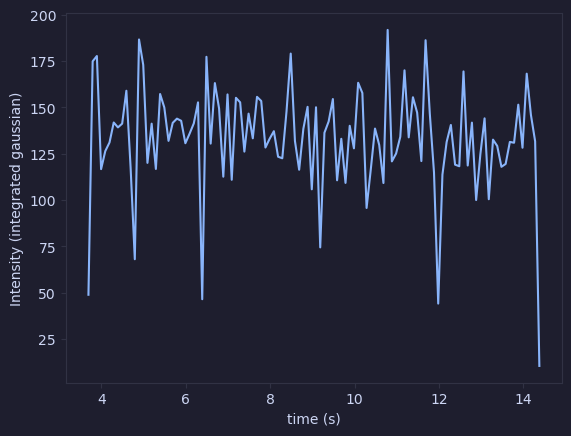

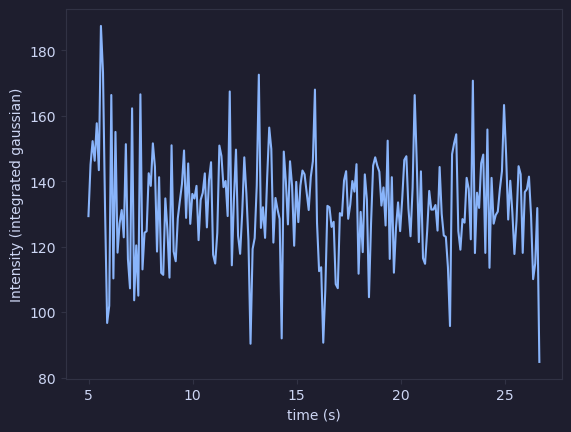

<Figure size 640x480 with 0 Axes>

In [ ]:
for i, track in enumerate(refinedtracks):
    plt.plot(track.seconds, track.photon_counts)
    plt.ylim(0,)
    plt.xlabel('time (s)')
    plt.ylabel('Intensity (integrated gaussian)')
    plt.show()
    plt.savefig('images/trace'+str(i)+'intensity.png')
    

## Exporting the data

Then we export both the data and a meta data file with all the tracking information, as well as the trace initialisation drawings

In [12]:

if not os.path.exists('traces'):
    os.makedirs('traces')
if not os.path.exists('trace_metadata'):
    os.makedirs('trace_metadata')
if not os.path.exists('initialisation_scribbles'):
    os.makedirs('initialisation_scribbles')
for i, track in enumerate(refinedtracks):
    tracename = name[:-3]+'_trace'+str(i)
    time = track.seconds
    posinum = [x for x in track.position] #here we add the um from start to get genomic position in um
    intensity = track.photon_counts
    df = pd.DataFrame({'time (s)':time, 'position (um)':posinum, 'intensity': intensity})
    df.to_csv('traces' +'/'+ tracename+'.csv', index=False)
    metadict = {'kymo filename':name,'timecrop1' : t1,'timecrop2' : t2,'poscrop1' : pos1,'poscrop2' : pos2, 'gaussianrefinementwindow': gaussianrefinementwindow}
    metaframe = pd.DataFrame(metadict,  index=[0]).transpose()
    metaframe.to_csv('trace_metadata'+'/'+tracename+'metadata.csv', header=False)
    scribble = pd.DataFrame({'time (s)': tracks[i].seconds, 'position (um)': tracks[i].position})
    scribble.to_csv('initialisation_scribbles'+'/'+tracename+'initialisation.csv', index=False)

## Calculating Diffusion by MSD/Tau

Now we can calculate diffusion coefficient

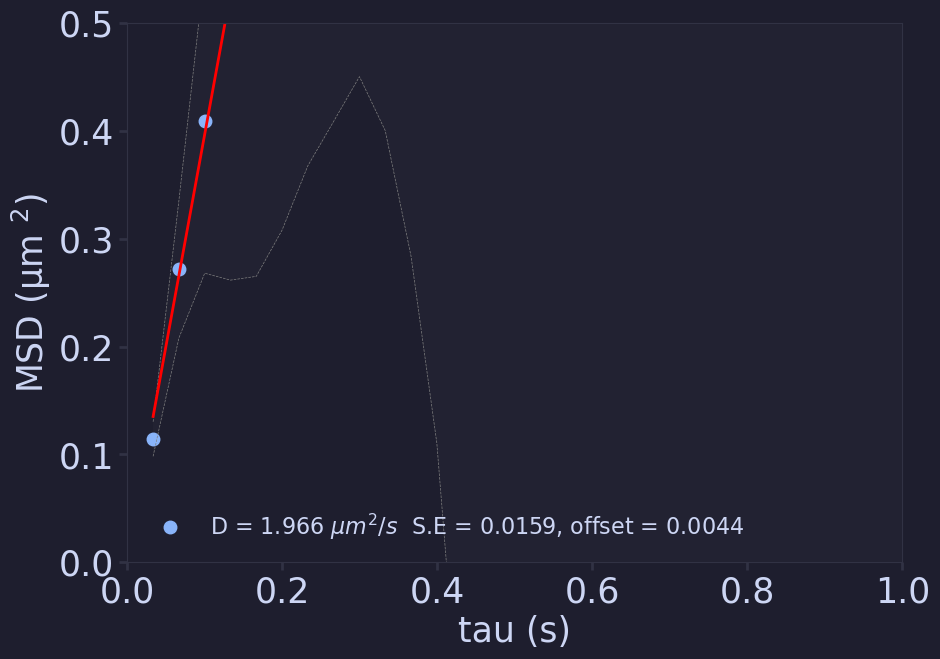

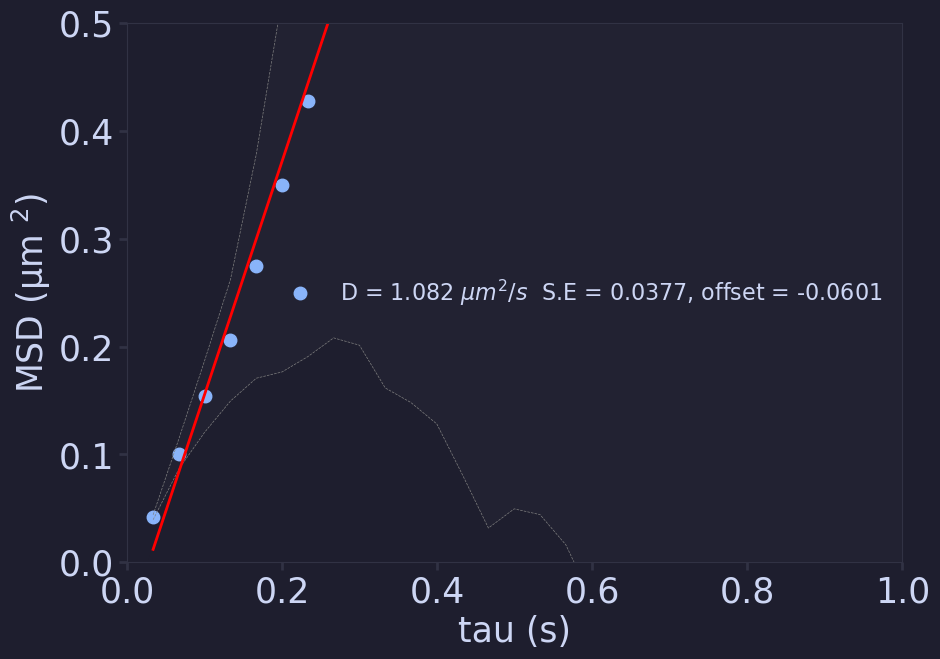

In [17]:
for track in refinedtracks:
    pos = track.position
    line_time = kymo.line_time_seconds
    window_min = 0
    window_max = 10

    N = len(pos)  # number of time frames (kymograph lines)
    SqD, MSD, MSD_local, tau, var_array, var_up, var_down = [],[],[],[],[],[],[]

    for n in range (1,N-3):        # probing different window sizes starting from n =1 (single linetime - dt) until N-1 (N-3 to be able to calculate variance of the last points)    
        tau = np.append(tau,[n*line_time],axis=0)
        SqD = []    
        for i in range (1,N-n):  # for each time window calculate square displacements between i and i+n frame        
            SqD = np.append(SqD,[(pos[i+n]-pos[i])**2],axis=0)
        MSD_point = np.sum(SqD)/(N-n)
        var = statistics.variance(SqD[:])    
        MSD = np.append(MSD,[np.sum(SqD)/(N-n)],axis=0)   # calculate mean square displacement for each window size
        var_array = np.append(var_array,[var],axis=0)
        var_up = np.append(var_up,[MSD_point+ 0.5*var],axis=0)
        var_down = np.append(var_down,[MSD_point- 0.5*var],axis=0)
    param,cov = np.polyfit(tau[window_min:window_max], MSD[window_min:window_max], 1,cov=True)
    y = param[0]*tau + param[1]
    #Standard error of the linear regression
    covMSD = (np.sqrt(np.diag(cov))) 
    # Plot MSD  #plot only 150x linetime, not the whole range (Still the whole range is saved)
    fig, ax = plt.subplots(figsize=(10, 7)) 
    ax.plot(tau,MSD,'o',markersize='9')
    ax.plot(tau[0:150],var_up[0:150],'--',color='grey',linewidth=0.5)
    ax.plot(tau[0:150],var_down[0:150],'--',color='grey',linewidth=0.5)
    plt.fill_between(tau[0:150], var_down[0:150], var_up[0:150], facecolor="grey", alpha=0.05)
    ax.plot(tau,y,'r',linewidth=1)
    ax.plot(tau[window_min:window_max],y[window_min:window_max],'r',linewidth=2)
    ax.tick_params(direction='out', length=6, width=2, labelsize= 25, grid_color='r', grid_alpha=0.5)
    ax.set_xlabel("tau (s)", fontsize=25)
    ax.set_ylabel("MSD (\u03BCm $^{2}$)", fontsize=25)
    '''CHOOSE AXIS RANGE TO VISUALIZE MSD'''
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 0.5])

    ax.legend(['D = ' + str(np.around(param[0]/2,decimals =3))+' $\u03BCm^2/s$ ' +  " S.E = " + str(np.around(covMSD[0]/2,decimals =4)) + ", offset = "+ str(np.around(param[1],decimals=4))],fontsize=16, frameon=False)
    plt.savefig('images/trace'+str(i)+'MSDtau.png')